## ETAPA 1 - Configuração

In [16]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import requests
import pandas as pd
import os
import time
import matplotlib.pyplot as plt

# sua API KEY
API_KEY = "acde196b-648e-4496-b387-2a5a5186436f"

url = "https://api.openchargemap.io/v3/poi/"

headers = {
    "X-API-Key": API_KEY,
    "User-Agent": "EV_Research/1.0",
    "Accept": "application/json"
}

# criar estrutura do projeto
os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [5]:
def get_data(country_code, country_name, max_results=200):
    
    params = {
        "output": "json",
        "countrycode": country_code,
        "maxresults": max_results,
        "compact": False,
        "verbose": False
    }
    
    response = requests.get(
        url,
        params=params,
        headers=headers,
        timeout=60
    )
    
    if response.status_code != 200:
        print(f"Erro em {country_name}: {response.status_code}")
        return []
    
    data = response.json()
    records = []
    
    for station in data:
        address = station.get("AddressInfo", {})
        operator = station.get("OperatorInfo", {})
        connections = station.get("Connections", [])
        
        if not connections:
            records.append({
                "country": country_name,
                "station_id": station.get("ID"),
                "city": address.get("Town"),
                "state": address.get("StateOrProvince"),
                "power_kw": None,
                "connection_type_id": None
            })
        
        else:
            for conn in connections:
                records.append({
                    "country": country_name,
                    "station_id": station.get("ID"),
                    "city": address.get("Town"),
                    "state": address.get("StateOrProvince"),
                    "power_kw": conn.get("PowerKW"),
                    "connection_type_id": conn.get("ConnectionTypeID")
                })
    
    return records

In [6]:
countries = [
    ("BR", "Brazil"),
    ("DE", "Germany"),
    ("FR", "France"),
    ("ES", "Spain"),
    ("MX", "Mexico")
]

all_records = []

for code, name in countries:
    print(f"Coletando: {name}")
    data = get_data(code, name, max_results=200)
    all_records.extend(data)
    time.sleep(2)

Coletando: Brazil
Coletando: Germany
Coletando: France
Coletando: Spain
Coletando: Mexico


In [7]:
df = pd.DataFrame(all_records)

print(df.shape)
print(df.head())

(1672, 6)
  country  station_id                    city state  power_kw  \
0  Brazil      486411                 Goiânia  None      23.0   
1  Brazil      486406  Maresias São Sebastião  None       7.0   
2  Brazil      486340           Vicente Pires  None      30.0   
3  Brazil      485972               Pinheiros  None      60.0   
4  Brazil      485972               Pinheiros  None      60.0   

   connection_type_id  
0                  25  
1                  25  
2                  33  
3                  33  
4                  33  


In [8]:
df = df.dropna(subset=["power_kw", "connection_type_id"])

In [9]:
connector_dict = {
    25: "Type 2",
    33: "CCS2",
    2: "CHAdeMO",
    1036: "Tesla",
    1040: "CCS1",
    27: "Type 1 (J1772)"
}

df["connector_name"] = df["connection_type_id"].map(connector_dict)

df = df.dropna(subset=["connector_name"])

In [10]:
# distribuição
print(df["connector_name"].value_counts())

# potência média por país e conector
stats = df.groupby(["country", "connector_name"])["power_kw"].describe()

print(stats)

connector_name
CCS2              634
Type 2            515
CHAdeMO           149
Tesla              83
Type 1 (J1772)     26
CCS1               22
Name: count, dtype: int64
                        count        mean        std    min    25%    50%  \
country connector_name                                                      
Brazil  CCS2            114.0   58.596491  38.394256    0.0   30.0   60.0   
        CHAdeMO           1.0   60.000000        NaN   60.0   60.0   60.0   
        Tesla             2.0   23.000000   0.000000   23.0   23.0   23.0   
        Type 2          222.0   15.130631   7.642230    3.0    7.0   22.0   
France  CCS2            273.0  170.798535  93.438363   24.0  100.0  160.0   
        CHAdeMO         116.0   50.637931   6.996144   24.0   50.0   50.0   
        Tesla             5.0   20.000000  14.404860    7.0    7.0   22.0   
        Type 2          139.0   21.892086   1.272283    7.0   22.0   22.0   
Germany CCS2            134.0  213.783582  84.215295   11

In [11]:
df.to_csv("data/ev_charging_global.csv", index=False, encoding="utf-8-sig")
print("Arquivo salvo em data/ev_charging_global.csv")

Arquivo salvo em data/ev_charging_global.csv


In [14]:
import matplotlib.pyplot as plt

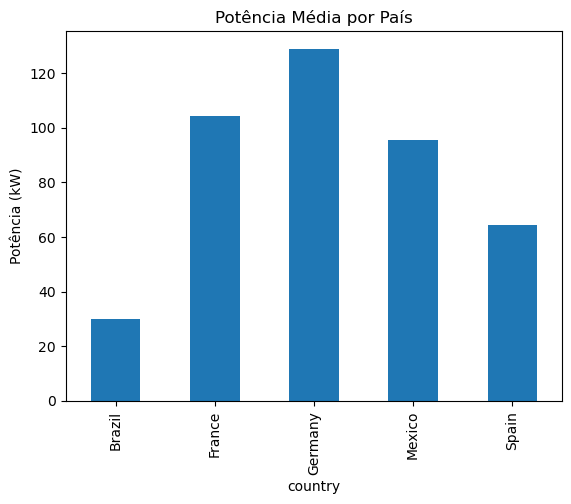

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# garantir que a pasta existe (boa prática)
os.makedirs("../figures", exist_ok=True)

# carregar dados
df = pd.read_csv("data/ev_charging_global.csv")

# gráfico
df.groupby("country")["power_kw"].mean().plot(kind="bar")

plt.title("Potência Média por País")
plt.ylabel("Potência (kW)")

# salvar no diretório correto
plt.savefig(
    "../figures/avg_power_country.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [18]:
import os
print(os.path.exists("figures/avg_power_country.png"))

True
